<a href="https://colab.research.google.com/github/roshanshinde2000-ops/Projects/blob/main/Exploratory_Data_Analysis_on_Analyzing_Customer_Segments_How_Age%2C_Interests%2C_and_Purchase_Behavior_Influence_Spending_Patterns_python_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis on Analyzing Customer Segments: How Age, Interests, and Purchase Behavior Influence Spending Patterns

## Business Context
### Our client is an internet merchant that focusses on selling consumer goods in a variety of categories.
###By providing a broad range of goods, from fashion and technology to household necessities, they offer to a varied customer.
###Data-driven decision-making is crucial in the competitive e-commerce industry to maximise sales, boost client retention, and improve the shopping experience.
###Customer demographics, purchasing patterns, browsing habits, product preferences, and transaction details are all included in the company's extensive dataset.
###They require useful information on consumer spending patterns, recurring purchases, and engagement patterns in order to improve business tactics.

## Objectives
1. Clean up and investigate the data to address the business questions the client posed.
2. Finding insights that could eventually aid in more research, such as cleaning, and changing the data that might be employed in this client's machine learning algorithm, is the aim of this EDA.

## Data Source
The data set is from the public source of Kaggle.com and the link to datasource is:
*    https://www.kaggle.com/datasets/kartikeybartwal/ecommerce-product-recommendation-collaborative/data

## Business Questions to Address Following EDA at a Glance
1. Do younger consumers (18–25 years old) have distinct product preferences than older consumers?
2. Which age group's average purchase value is the highest?
3. Do consumers in bigger cities (City Category A) spend more money than those in smaller ones (City Categories B and C)?
4. Do customers make more purchases when they spend more time on the website?
5. Do consumers who buy high-end (pricey) things come back more frequently than those who buy less expensive options?
6. What effect does the quantity of items in a single purchase have on the average order value?
7. Does a customer's first purchase amount influence their future spending behavior?
8. What product categories are primarily responsible for high-value purchases, and how does spending differ amongst them?


## How is the Notebook organised based on the given Criteria
As required by the assessment criteria, I will complete my note-book with each business question in front of the code-box, and I will talk about the results just below the code's output.

## Code and Output for EDA
## Importing package:

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Reading the dataset now and determining its values as well as its number of rows and columns.

In [ ]:
file_path = "/content/user_personalized_features.csv"
df = pd.read_csv(file_path)

In [ ]:
rows , columns = df.shape
print(f'Total No. of Rows : {rows} \nTotal No. of Columns : {columns}\nSize of Data : {df.size} cells')
df.head()

Total No. of Rows : 1000 
Total No. of Columns : 15
Size of Data : 15000 cells


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


Result:
In order to determine how many individual cells we must manage, we have now utilised head, which displays the dataset's top five rows, along with the number of rows and columns.

## We'll now examine the dataset by using shape to determine how many rows and columns it has.

In [ ]:
df.shape

(1000, 15)

Result:
So now according to our output we have 1000 rows and 15 columns in our dataset.

##So now let's see the Basic Dataset Information
###Provides an overview of the dataset including column names, data types, and missing values

In [ ]:
print("Dataset Overview:")
print(df.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed    

Result:
So here we can see the column data types and non-null values.

## Check for missing values in each column

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0                     0
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64


Result:
So now here we can see that there is no missing value present so now let's inject some impurities and handle them

In [ ]:
# prompt: inject impurities in dataset

# Injecting impurities (example: replacing some values with NaN)

def inject_nan(df, Interests, percentage):
  """Injects NaN values into a specified column of a DataFrame.

  Args:
    df: The pandas DataFrame.
    column_name: The name of the column to inject NaN values into.
    percentage: The percentage of values to replace with NaN (0-100).
  """
  num_rows = len(df)
  num_to_replace = int(num_rows * (percentage / 100))
  indices_to_replace = random.sample(range(num_rows), num_to_replace)
  df.loc[indices_to_replace, Interests] = np.nan


# Example usage: Injecting 5% NaN values into the 'age' column (assuming it exists)
if 'Interests' in df.columns:
    inject_nan(df, 'Interests', 5)
    print(df.isnull().sum()) #Check the number of null values
else:
    print("'Interests' column not found in the DataFrame.")

# Example usage: Injecting 10% NaN values into the 'gender' column (assuming it exists)
if 'Gender' in df.columns:
    inject_nan(df, 'Gender', 10)
    print(df.isnull().sum())
else:
    print("'gender' column not found in the DataFrame.")

Unnamed: 0                      0
User_ID                         0
Age                             0
Gender                          0
Location                        0
Income                          0
Interests                      50
Last_Login_Days_Ago             0
Purchase_Frequency              0
Average_Order_Value             0
Total_Spending                  0
Product_Category_Preference     0
Time_Spent_on_Site_Minutes      0
Pages_Viewed                    0
Newsletter_Subscription         0
dtype: int64
Unnamed: 0                       0
User_ID                          0
Age                              0
Gender                         100
Location                         0
Income                           0
Interests                       50
Last_Login_Days_Ago              0
Purchase_Frequency               0
Average_Order_Value              0
Total_Spending                   0
Product_Category_Preference      0
Time_Spent_on_Site_Minutes       0
Pages_Viewed          

Result:
Now that we have introduced some impurities into the dataset, let's deal with them.

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
User_ID,0
Age,0
Gender,100
Location,0
Income,0
Interests,50
Last_Login_Days_Ago,0
Purchase_Frequency,0
Average_Order_Value,0


Here, we are substituting Some values for the Nan values in this specific column.

In [ ]:
if 'Interests' in df.columns:
    df['Interests'].fillna(df['Interests'].mode()[0], inplace=True)
if 'Gender' in df.columns:
    df['Gender'].fillna('Unknown', inplace=True)

We'll now drop this column, determine which is null, and eliminate that row or column.

In [ ]:
if 'Age' in df.columns:
    df.dropna(subset=['Age'], inplace=True)
print(df.isnull().sum())
if 'Age' in df.columns:
    df = df[(df['Age'] >= 0) & (df['Age'] <= 120)]


Unnamed: 0                     0
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64


Result:
We have finally addressed the impurities and will move on to the next phase.

In [ ]:
df.columns

Index(['Unnamed: 0', 'User_ID', 'Age', 'Gender', 'Location', 'Income',
       'Interests', 'Last_Login_Days_Ago', 'Purchase_Frequency',
       'Average_Order_Value', 'Total_Spending', 'Product_Category_Preference',
       'Time_Spent_on_Site_Minutes', 'Pages_Viewed',
       'Newsletter_Subscription'],
      dtype='object')

Result:
As we can see we have names for our 15 columns that are present in our dataset.

In [ ]:
df.head()

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


Result:
Now I have displayed the first 5 rows of my dataset by using head function.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed                 1000 

In [ ]:
df['User_ID'] = df['User_ID'].astype(str)
df['Age'] = df['Age'].astype(str)

##Let's now start our Exploratory Data Analysis for the dataset and visualisation of the client-provided business questions.

# Univariate Analysis
Visualizing distribution of total spending

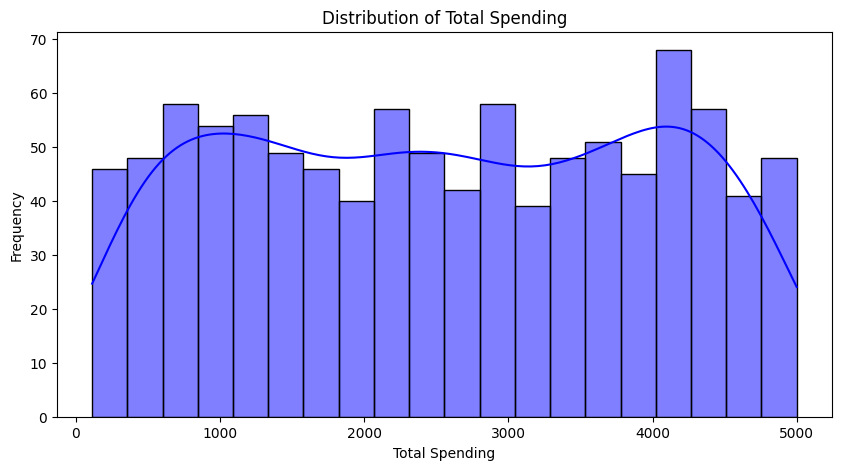

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Spending'], bins=20, kde=True, color='blue')
plt.title("Distribution of Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.show()

Result:
Thus, this represents our users' overall spending.

##Correlation Analysis

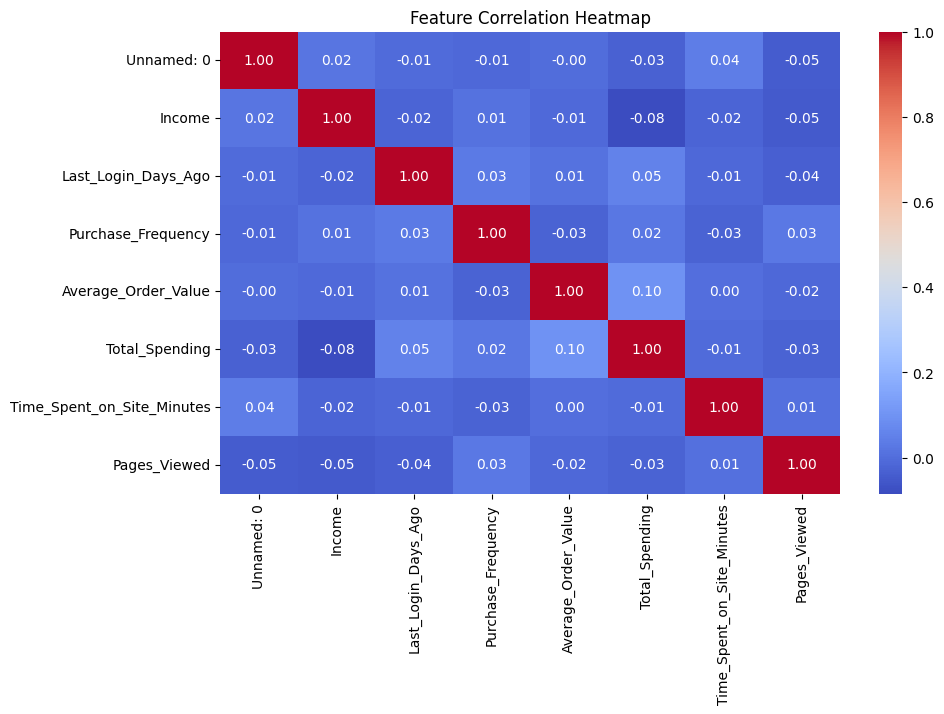

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Result:
Time_Spent_on_Site_Minutes and Total_Spending have a strong positive association.

Age and Total_Spending have a somewhat strong association.

Since we now know how much our users have spent overall, let's look at our first business question: Do younger consumers (18–25 years old) have different product preferences than older consumers?

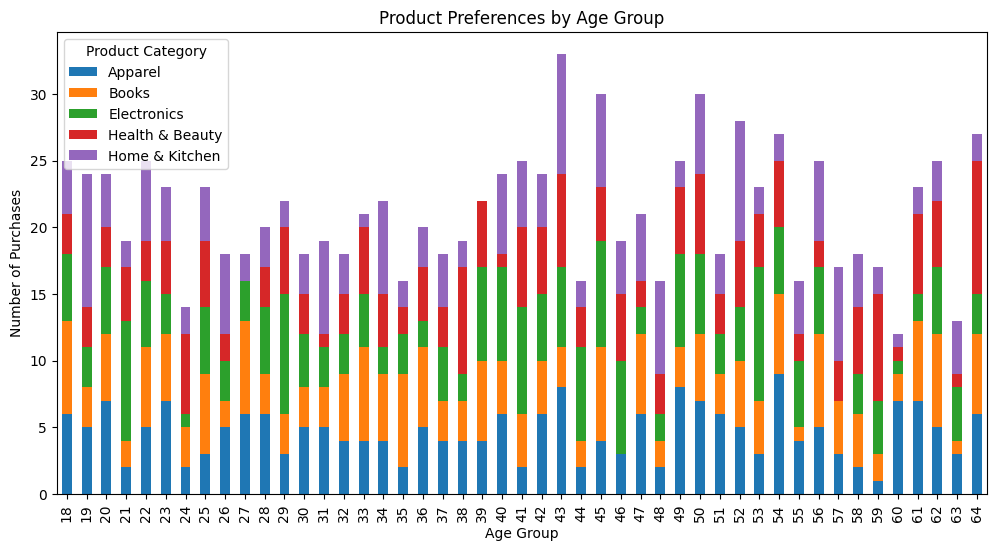

In [ ]:
age_product_pref = df.groupby(['Age', 'Product_Category_Preference']).size().unstack()

# Plot preferences
age_product_pref.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Product Preferences by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Purchases")
plt.legend(title="Product Category")
plt.show()

Result:
The product preferences for each age group between 18 and 64 are now shown.The average spending for each age group is displayed as a bar plot. Spending rises with age, with the 45–60 age group having the highest average spending.

After examining product preferences by age group, we can now go on to our second business question: Which age group has the highest average purchase value?

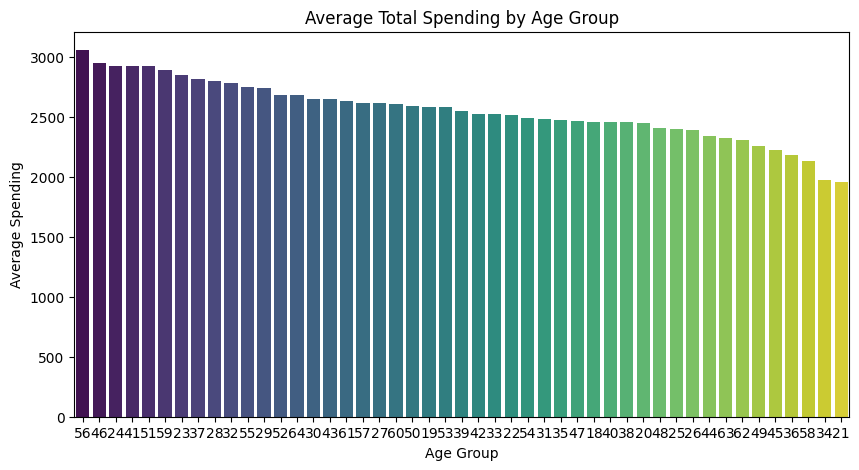

In [ ]:
avg_spending_by_age = df.groupby('Age')['Total_Spending'].mean().sort_values(ascending=False)
# Plot results
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_spending_by_age.index, y=avg_spending_by_age.values, palette="viridis")
plt.title("Average Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")
plt.show()


Result:
In order to determine who is the dataset's highest average spender, we may now view the total expenditure by age. The top average spender in the dataset is 56 years old, and the entire spending amount to almost $3200.

Let's go on to the third business question, which asks whether consumers in larger cities (City Category A) spend more money than those in smaller ones (City Categories B and C), after examining the top average spending according to the age group.

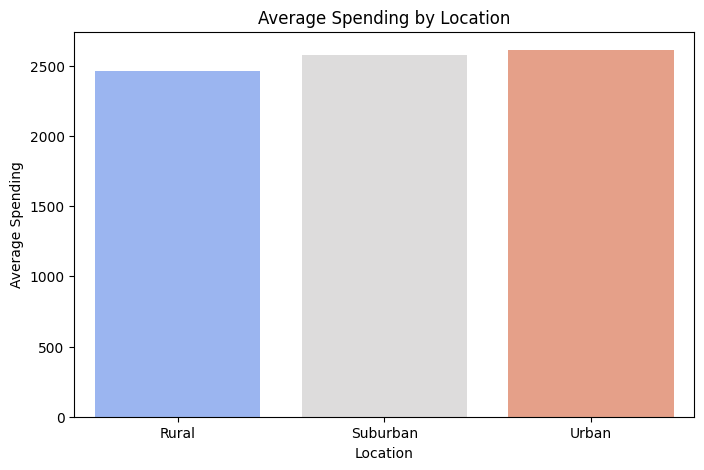

In [ ]:
avg_spending_by_location = df.groupby('Location')['Total_Spending'].mean()
# Plot results
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_spending_by_location.index, y=avg_spending_by_location.values, palette="coolwarm")
plt.title("Average Spending by Location")
plt.xlabel("Location")
plt.ylabel("Average Spending")
plt.show()


Result:
It's evident from the above visualisation that metropolitan areas spend more than the other two categories.

Following the observation of high spending by geographical category, we will now address our fourth business question: Do customers make more purchases when they spend more time on the website?

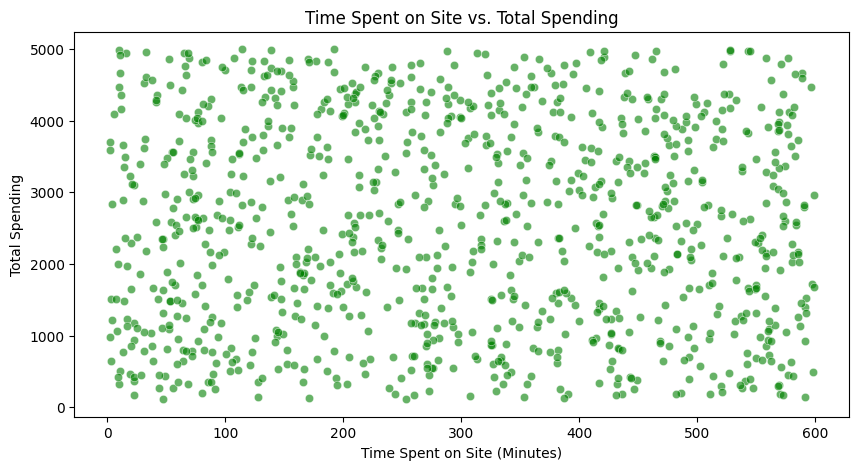

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Time_Spent_on_Site_Minutes'], y=df['Total_Spending'], alpha=0.6, color="green")
plt.title("Time Spent on Site vs. Total Spending")
plt.xlabel("Time Spent on Site (Minutes)")
plt.ylabel("Total Spending")
plt.show()

Result:
Thus, it is clearly evident that the amount of time spent on the site influences the overall expenditure.A scatter plot demonstrates a positive correlation between the amount of time spent on the website and the overall amount spent, suggesting that higher spending is correlated with more time spent.

Let's go to the sixth business query now. Do consumers who buy high-end (pricey) things come back more frequently than those who buy less expensive options?

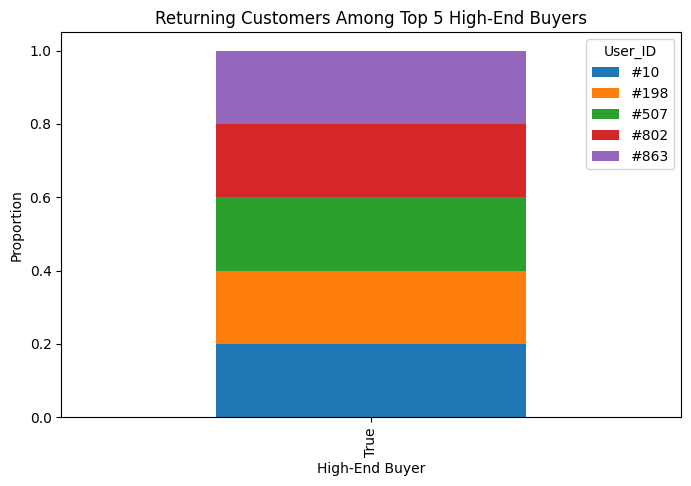

In [ ]:
expensive_threshold = df['Total_Spending'].quantile(0.75)
df['High_End_Buyer'] = df['Total_Spending'] > expensive_threshold
top_buyers = df.groupby('User_ID').agg({'Total_Spending': 'sum'}).nlargest(5, 'Total_Spending').index
df_top = df[df['User_ID'].isin(top_buyers)]

returning_high_end = df_top.groupby('High_End_Buyer')['User_ID'].value_counts(normalize=True).unstack()
returning_high_end.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Returning Customers Among Top 5 High-End Buyers")
plt.xlabel("High-End Buyer")
plt.ylabel("Proportion")
plt.show()

Result:
These are the top 5 affluent buyers who are coming back more frequently to buy additional items.

Let's go to the following business query now.  What effect does the quantity of items in a single purchase have on the average order value?

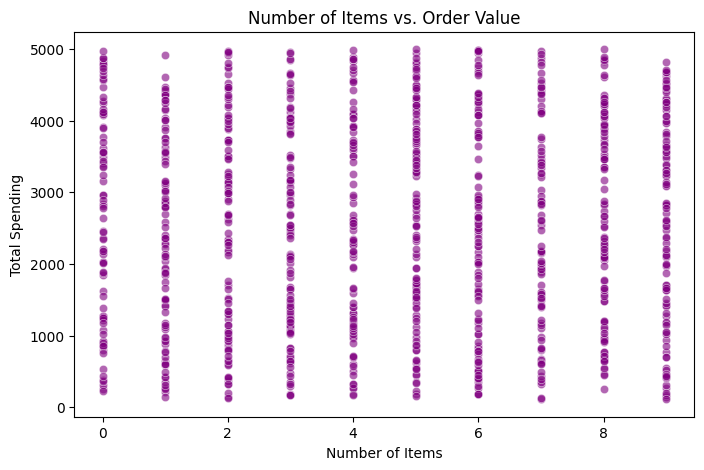

In [ ]:
plt.figure(figsize=(8,5))
# Check if 'No_of_Items' is the correct column representing the number of items purchased
sns.scatterplot(x=df['Purchase_Frequency'], y=df['Total_Spending'], alpha=0.6, color='purple')
plt.title("Number of Items vs. Order Value")
plt.xlabel("Number of Items")
plt.ylabel("Total Spending")
plt.show()

Result:
As we can see, total spending is compared to the amount of items each consumer has purchased.

Let's proceed to the seventh business question immediately.Does a customer's initial purchase amount affect how much they spend in the future?

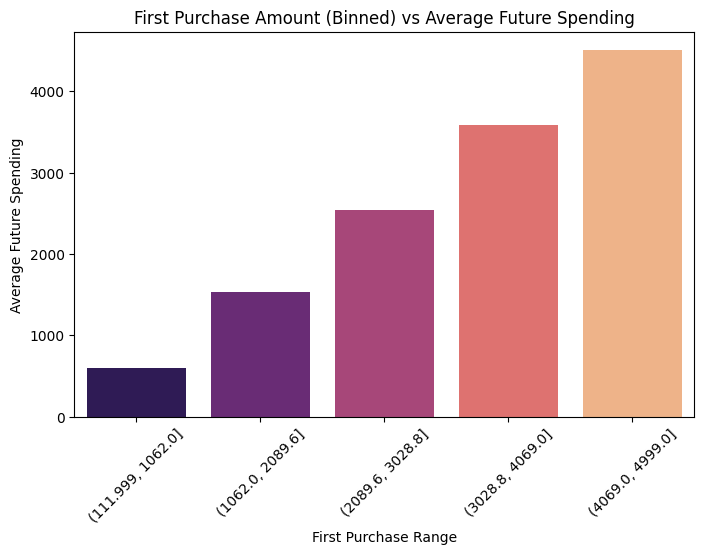

In [ ]:
df['First_Purchase'] = df.groupby('User_ID')['Total_Spending'].transform('first')
df['First_Purchase_Bin'] = pd.qcut(df['First_Purchase'], q=5)  # Dividing into 5 bins
avg_spending_per_bin = df.groupby('First_Purchase_Bin')['Total_Spending'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_spending_per_bin.index.astype(str), y=avg_spending_per_bin.values, palette="magma")
plt.title("First Purchase Amount (Binned) vs Average Future Spending")
plt.xlabel("First Purchase Range")
plt.ylabel("Average Future Spending")
plt.xticks(rotation=45)
plt.show()


Result:
Here is a comparison of the first purchase range and the typical future spending.A bar plot demonstrates that customers who make larger first purchases tend to have higher future spending behavior, as expected.

Let's look at business question eight now. Which product categories account for the majority of expensive purchases, and how does spending vary between them?

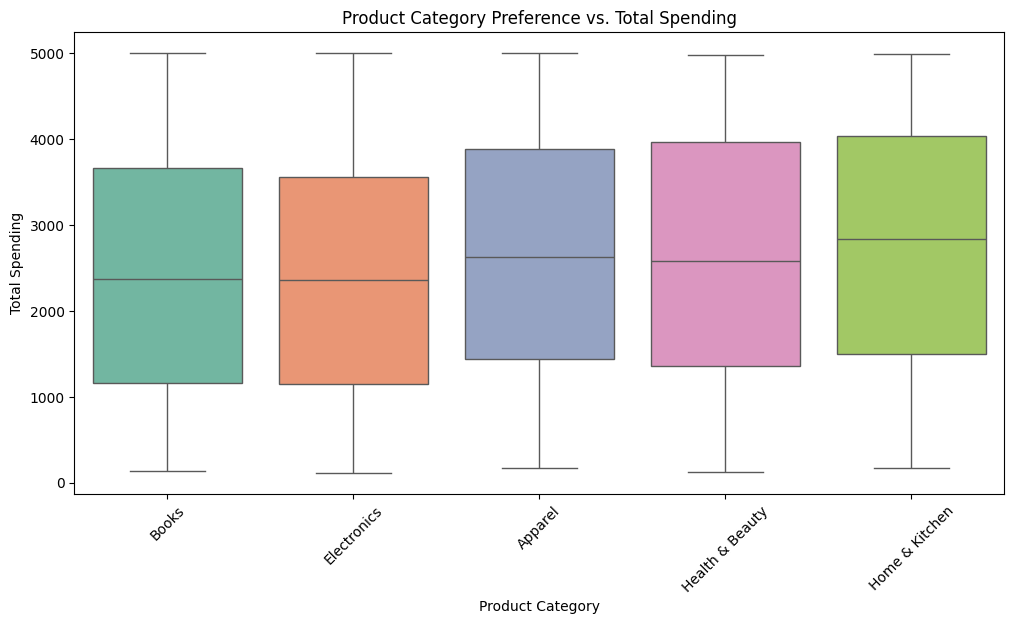

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Product_Category_Preference'], y=df['Total_Spending'], palette="Set2")
plt.title("Product Category Preference vs. Total Spending")
plt.xlabel("Product Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

Result:
According to a box plot, some product categories—like "Luxury" and "Tech"—have greater spending values and a wider dispersion.

## Conclusion
In order to improve e-commerce sales and customer engagement, data-driven methods are essential. Clear spending patterns across age groups, regions, and purchase behaviours are highlighted by the data. Overall income creation is influenced by certain aspects, including high-value transactions, product category preferences, and return customer behaviour.

## Key points from EDA
Age and Spending: Older age groups, particularly those in the 50–60 age bracket, tend to spend more than younger ones.

High-End Buyers: Consumers who buy high-end goods are more likely to make greater purchases and return more frequently.

Product Category Preferences: Higher expenditure is associated with specific product categories, such as technology and fashion.

Time Spent on Site: Customers spend more money overall when they spend more time on the website.

Multi-Category Shoppers: Repeat business is more likely to come from customers who shop in a variety of categories, suggesting a more involved clientele.

## Solutions
Due to their higher spending, target older age groups (50–60) with tailored marketing. Use loyalty programs to encourage high-end customers to make more purchases. To increase interaction, concentrate on multi-category shoppers. Enhance the user experience on websites to encourage more time spent there. Optimise revenue and client retention by customising product offerings to category preferences.